In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix,mean_squared_error, classification_report
import tensorflow as tf
import tensorflow.lite as tflite
import joblib

In [97]:
# Load cleaned data
groundwater_file = "MLProjectData/groundWaterQuality_Final_Dataset(in).csv"
motor_file = "MLProjectData/measures_v2.csv"

groundwater_df = pd.read_csv(groundwater_file, encoding="ISO-8859-1")
# motor_df = pd.read_csv(motor_file, encoding="ISO-8859-1", skiprows=1)
motor_df = pd.read_csv(motor_file, encoding="ISO-8859-1", skiprows=1, names=[
    "index", "ambient", "coolant", "u_d", "u_q", "speed", "i_d", "i_q", "pm", "yoke", "tooth", "winding", "profile_id"
])

C:\Users\atulm\AppData\Local\Temp\ipykernel_12688\3660939073.py:7: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  motor_df = pd.read_csv(motor_file, encoding="ISO-8859-1", skiprows=1, names=[


In [98]:
# Drop unnecessary columns
groundwater_df = groundwater_df.drop(columns=["STATION CODE"])
groundwater_df = groundwater_df.drop(columns=["LOCATIONS"])
groundwater_df = groundwater_df.drop(columns=["STATE"])
motor_df = motor_df.drop(columns=["index", "profile_id"])
# motor_df = motor_df.drop(columns=["profile_id"])

In [99]:
# Handle missing values
for col in groundwater_df.select_dtypes(include=['number']).columns:
    groundwater_df[col].fillna(groundwater_df[col].median(), inplace=True)
for col in groundwater_df.select_dtypes(include=['object']).columns:
    groundwater_df[col].fillna(groundwater_df[col].mode()[0], inplace=True)

for col in motor_df.select_dtypes(include=['number']).columns:
    motor_df[col].fillna(motor_df[col].median(), inplace=True)
for col in motor_df.select_dtypes(include=['object']).columns:
    motor_df[col].fillna(motor_df[col].mode()[0], inplace=True)

C:\Users\atulm\AppData\Local\Temp\ipykernel_12688\1428266268.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  groundwater_df[col].fillna(groundwater_df[col].median(), inplace=True)
C:\Users\atulm\AppData\Local\Temp\ipykernel_12688\1428266268.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [100]:
# Remove invalid values
motor_df.replace([np.inf, -np.inf], np.nan, inplace=True)
motor_df.dropna(inplace=True)
groundwater_df.replace([np.inf, -np.inf], np.nan, inplace=True)
groundwater_df.dropna(inplace=True)

In [101]:
# Smoothing noisy sensor data using Savitzky-Golay filter
sensor_columns = ["pH", "turbidity", "ambient", "coolant", "vibration"]
for col in sensor_columns:
    if col in groundwater_df.columns and len(groundwater_df[col]) >= 5:
        groundwater_df[col] = savgol_filter(groundwater_df[col], window_length=5, polyorder=2)
    if col in motor_df.columns and len(motor_df[col]) >= 5:
        motor_df[col] = savgol_filter(motor_df[col], window_length=5, polyorder=2)

In [140]:
# Feature engineering
if "pH : Mean : 6.5-8.5" in groundwater_df.columns and "turbidity" in groundwater_df.columns:
    groundwater_df["water_quality_index"] = groundwater_df["pH"] * groundwater_df["turbidity"]

if "ambient" in motor_df.columns and "coolant" in motor_df.columns:
    motor_df["temp_diff"] = motor_df["ambient"] - motor_df["coolant"]

In [141]:
# Splitting data for regression
X = motor_df.drop(columns=['ambient'])
y = motor_df['ambient']

In [142]:
print("Groundwater dataset size:", groundwater_df.shape)
print("Motor dataset size:", motor_df.shape)

Groundwater dataset size: (983, 21)
Motor dataset size: (1242400, 13)


In [143]:
# Ensure no NaN or infinite values in dataset
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y.dropna(inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [144]:
# Train XGBoost model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred))
print("XGBoost Parameters:", xgb_model.get_params())

XGBoost MAE: 0.5402569701732901
XGBoost Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [145]:
# Convert XGBoost model to TensorFlow Lite for Edge Deployment
joblib.dump(xgb_model, "xgb_model.pkl")  # Save model in standard format


['xgb_model.pkl']

In [146]:
# Train Isolation Forest for anomaly detection
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_train)
anomalies = iso_forest.predict(X_test)
motor_df['anomaly'] = iso_forest.predict(X)

Isolation Forest Accuracy: 0.4918544752092724
Confusion Matrix:
[[  5164 119076]
 [  7188 117052]]


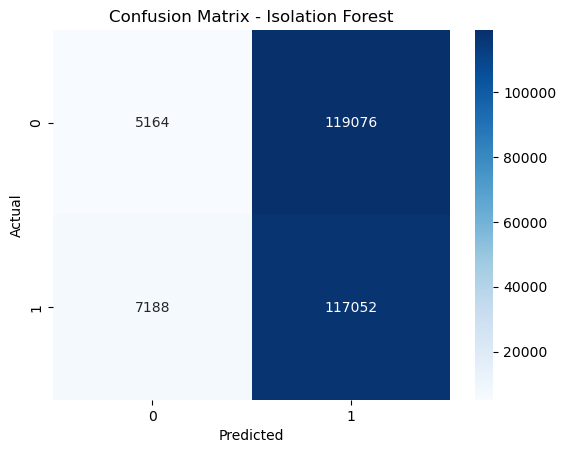

In [109]:
# Evaluate Isolation Forest
accuracy = accuracy_score(y_test > y_test.median(), anomalies > 0)
print("Isolation Forest Accuracy:", accuracy)
print("Confusion Matrix:")
cm = confusion_matrix(y_test > y_test.median(), anomalies > 0)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Isolation Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [120]:
print("Classification Report:")
print(classification_report(y_test > y_test.median(), anomalies > 0))

Classification Report:
              precision    recall  f1-score   support

       False       0.42      0.04      0.08    124240
        True       0.50      0.94      0.65    124240

    accuracy                           0.49    248480
   macro avg       0.46      0.49      0.36    248480
weighted avg       0.46      0.49      0.36    248480



In [117]:
# Making predictions using the trained XGBoost model
y_pred = xgb_model.predict(X_test)

In [121]:
# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.7264277858784073
R² Score: 0.9983844462718491


In [122]:
# Testing model on unseen data (using a different portion of the dataset)
X_unseen = X.sample(n=10, random_state=42)  # Taking a random sample from the dataset
y_unseen_actual = y.loc[X_unseen.index]
y_unseen_pred = xgb_model.predict(X_unseen)

print("Predictions on Unseen Data:")
for actual, predicted in zip(y_unseen_actual, y_unseen_pred):
    print(f"Actual: {actual}, Predicted: {predicted}")

Predictions on Unseen Data:
Actual: 75.89650254663198, Predicted: 74.0336685180664
Actual: 18.400559398106154, Predicted: 19.819311141967773
Actual: 18.56841681344168, Predicted: 18.580812454223633
Actual: 46.741527676172936, Predicted: 45.59477996826172
Actual: 38.38151606824208, Predicted: 38.48594665527344
Actual: 85.89083213054698, Predicted: 84.0944595336914
Actual: 18.92362049647739, Predicted: 18.9974308013916
Actual: 18.30461605616977, Predicted: 18.507373809814453
Actual: 19.13168247767856, Predicted: 18.81035041809082
Actual: 28.149817031481618, Predicted: 28.22728729248047


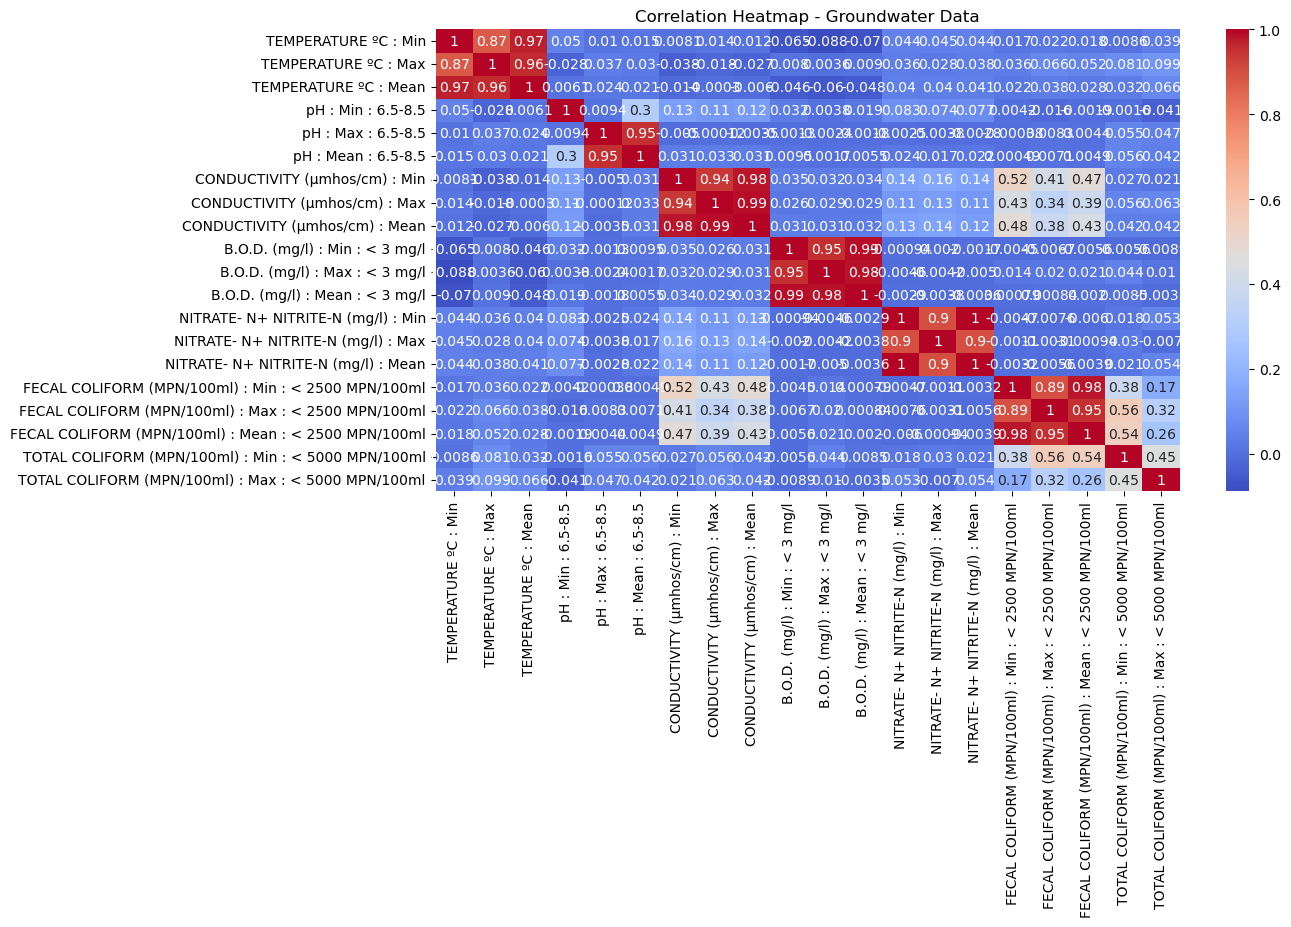

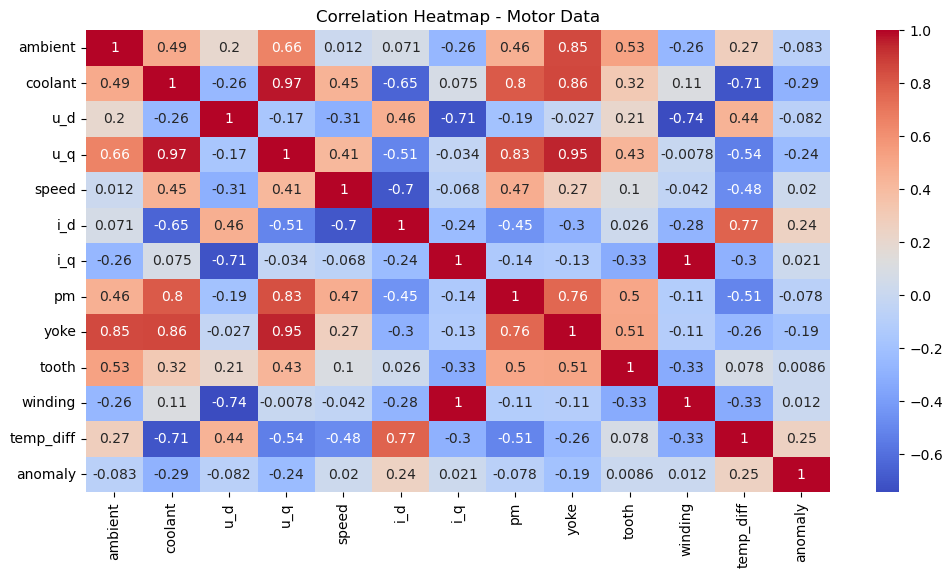

In [123]:
# Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(groundwater_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Groundwater Data')
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(motor_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Motor Data')
plt.show()


In [124]:
print("Classification Report:")
print(classification_report(y_test > y_test.median(), anomalies > 0))


Classification Report:
              precision    recall  f1-score   support

       False       0.42      0.04      0.08    124240
        True       0.50      0.94      0.65    124240

    accuracy                           0.49    248480
   macro avg       0.46      0.49      0.36    248480
weighted avg       0.46      0.49      0.36    248480



C:\Users\atulm\miniconda3\envs\tf-gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


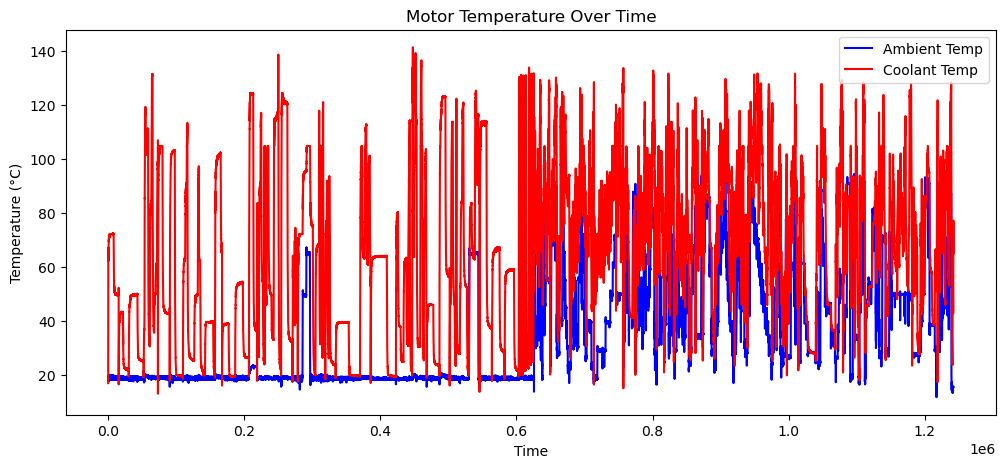

In [126]:
# Time-series plot for motor temperature
plt.figure(figsize=(12, 5))
plt.plot(motor_df.index, motor_df['ambient'], label='Ambient Temp', color='blue')
plt.plot(motor_df.index, motor_df['coolant'], label='Coolant Temp', color='red')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.title('Motor Temperature Over Time')
plt.show()

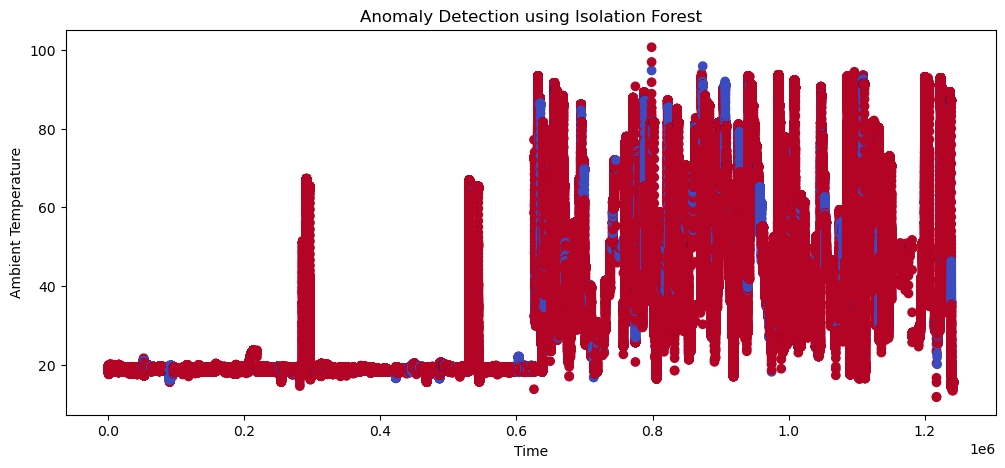

In [127]:
# Anomaly visualization
plt.figure(figsize=(12, 5))
plt.scatter(motor_df.index, motor_df['ambient'], c=motor_df['anomaly'], cmap='coolwarm', marker='o')
plt.xlabel('Time')
plt.ylabel('Ambient Temperature')
plt.title('Anomaly Detection using Isolation Forest')
plt.show()

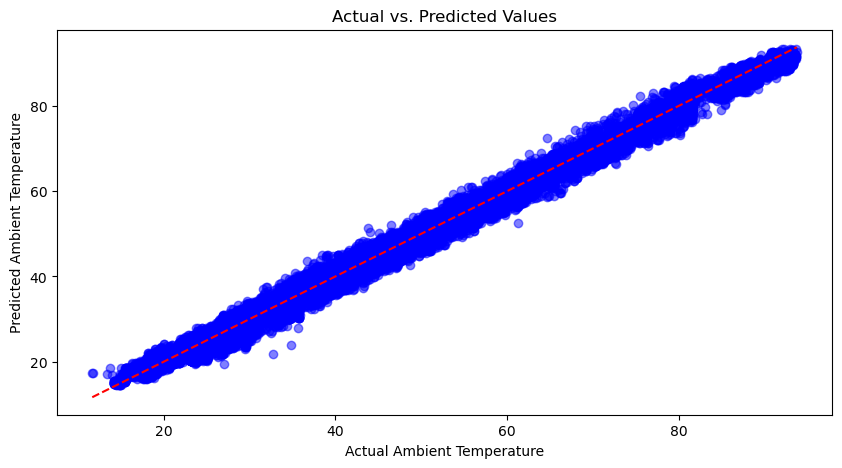

In [128]:
# Residual Plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Actual Ambient Temperature')
plt.ylabel('Predicted Ambient Temperature')
plt.title('Actual vs. Predicted Values')
plt.show()

In [147]:
# Residual Plot for Water Quality Prediction
plt.figure(figsize=(10, 5))
plt.scatter(groundwater_df['pH : Mean : 6.5-8.5'], groundwater_df['water_quality_index'], alpha=0.5, color='green')
plt.xlabel('Actual pH Levels')
plt.ylabel('Predicted Water Quality Index')
plt.title('Actual vs. Predicted Water Quality')
plt.show()

KeyError: 'water_quality_index'

<Figure size 1000x500 with 0 Axes>

In [148]:
print(groundwater_df.columns)

Index(['TEMPERATURE ºC : Min', 'TEMPERATURE ºC : Max', 'TEMPERATURE ºC : Mean',
       'pH : Min : 6.5-8.5', 'pH : Max : 6.5-8.5', 'pH : Mean : 6.5-8.5',
       'CONDUCTIVITY (µmhos/cm) : Min', 'CONDUCTIVITY (µmhos/cm) : Max',
       'CONDUCTIVITY (µmhos/cm) : Mean', 'B.O.D. (mg/l) : Min : < 3 mg/l',
       'B.O.D. (mg/l) : Max : < 3 mg/l', 'B.O.D. (mg/l) : Mean : < 3 mg/l',
       'NITRATE- N+ NITRITE-N (mg/l) : Min',
       'NITRATE- N+ NITRITE-N (mg/l) : Max',
       'NITRATE- N+ NITRITE-N (mg/l) : Mean',
       'FECAL COLIFORM (MPN/100ml) : Min : < 2500 MPN/100ml',
       'FECAL COLIFORM (MPN/100ml) : Max : < 2500 MPN/100ml',
       'FECAL COLIFORM (MPN/100ml) : Mean : < 2500 MPN/100ml',
       'TOTAL COLIFORM (MPN/100ml) : Min : < 5000 MPN/100ml',
       'TOTAL COLIFORM (MPN/100ml) : Max : < 5000 MPN/100ml',
       'TOTAL COLIFORM (MPN/100ml) : Mean : < 5000 MPN/100ml'],
      dtype='object')
